In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:

# Load  dataset
combined_df = pd.read_csv("../training-testing-data/transfer_dataset.csv")

#  training data (2020-2023) for eda as do not want to analyse the testing data so we prevent data leakage
training_seasons = [2020, 2021, 2022, 2023]
train_df = combined_df[combined_df['season'].isin(training_seasons)].copy()

print(f"Total transfers: {len(combined_df)}")
print(f"Training data transfers for EDA: {len(train_df)}")


Total transfers: 2464
Training data transfers for EDA: 1915


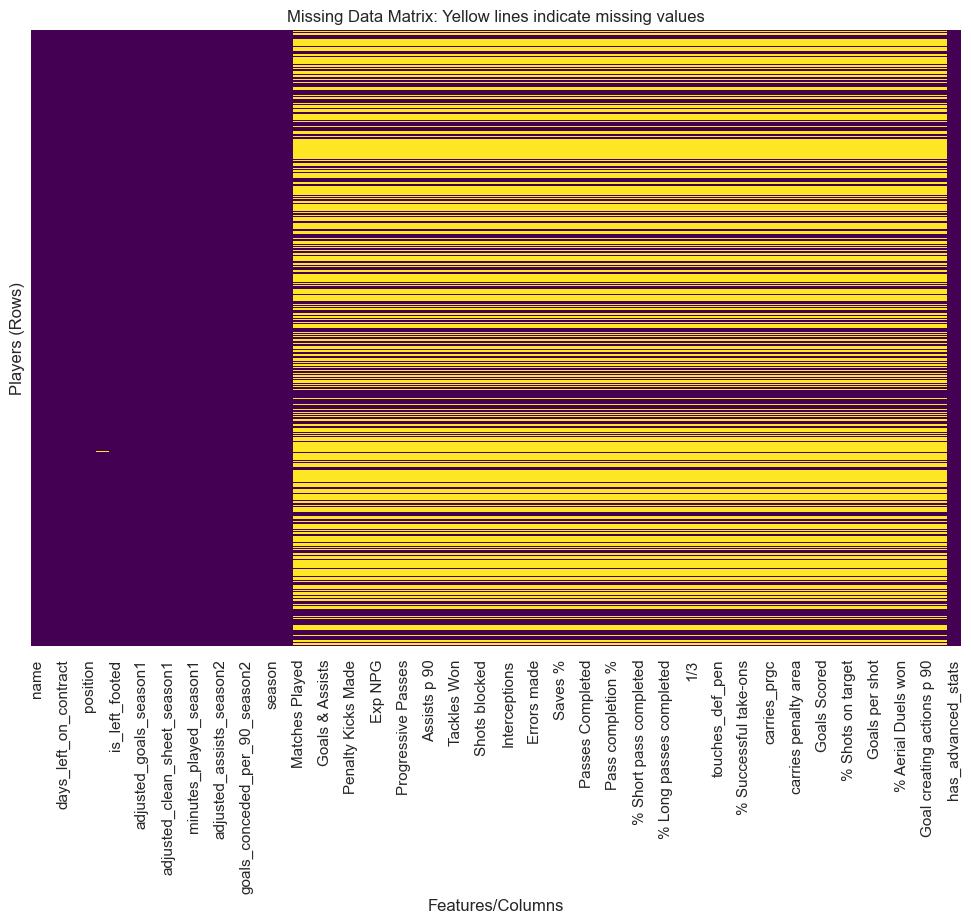

Percentage of missing advanced stats: 57.96%


In [14]:


plt.figure(figsize=(12, 8))
# train_df.isnull() creates a True/False matrix. True (missing) will be plotted as yellow.
sns.heatmap(train_df.isnull(), cbar=False, cmap='viridis', yticklabels=False)

plt.title('Missing Data Matrix: Yellow lines indicate missing values')
plt.xlabel('Features/Columns')
plt.ylabel('Players (Rows)')
plt.show()

# print the percentage of players with missing advanced stats
pct_missing_xg = train_df['has_advanced_stats']==0
lol=pct_missing_xg.mean() * 100
print(f"Percentage of missing advanced stats: {lol:.2f}%")

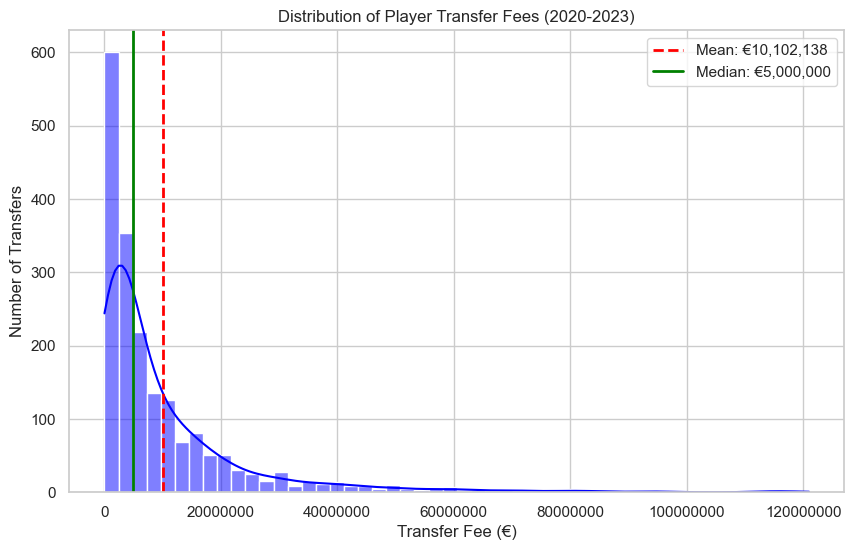

In [7]:
# background style
sns.set_theme(style="whitegrid")

#  size of the image
plt.figure(figsize=(10, 6))

#Create histogram
# data = training data
# x = our target which is transfer value 
# bins = how many buckets to divide the data into 
# kde = True adds a curve to show the geenral shape of the graph
sns.histplot(data=train_df, x='transfer_fee', bins=50, kde=True, color='blue')

# --- Add mean and median lines ---
mean_val = train_df['transfer_fee'].mean()
median_val = train_df['transfer_fee'].median()

plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: €{mean_val:,.0f}')
plt.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: €{median_val:,.0f}')

plt.legend()
# ---------------------------------

#add titles 
plt.title('Distribution of Player Transfer Fees (2020-2023)')
plt.xlabel('Transfer Fee (€)')
plt.ylabel('Number of Transfers')

# prevents using natural numbers e.g e for  big numbers
plt.ticklabel_format(style='plain')

# show graph
plt.show()

TypeError: ticklabel_format() got an unexpected keyword argument 'agevfeeis'

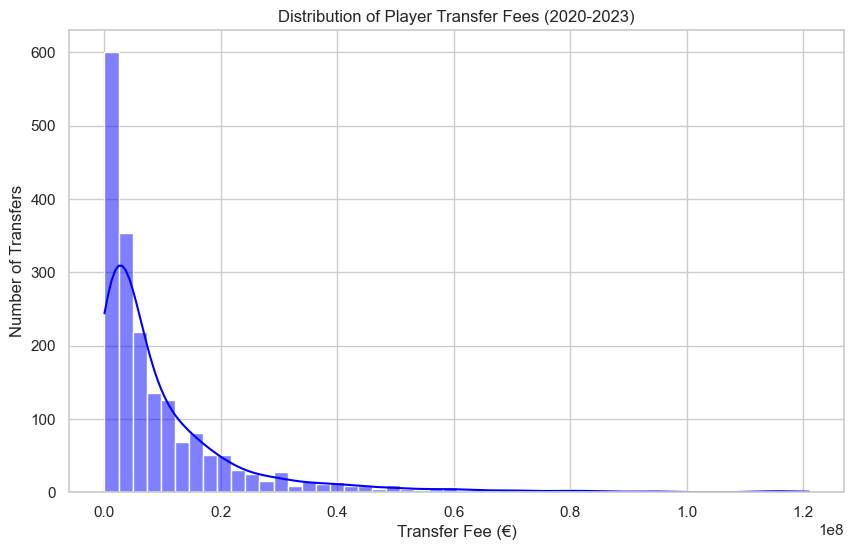

In [8]:


# background style
sns.set_theme(style="whitegrid")

#  size of the image
plt.figure(figsize=(10, 6))

#Create histogram
# data = training data
# x = our target which is transfer value 
# bins = how many buckets to divide the data into 
# kde = True adds a curve to show the geenral shape of the graph
sns.histplot(data=train_df, x='transfer_fee', bins=50, kde=True, color='blue')

#add titles 
plt.title('Distribution of Player Transfer Fees (2020-2023)')
plt.xlabel('Transfer Fee (€)')
plt.ylabel('Number of Transfers')

# prevents using natural numbers e.g e for  big numbers
plt.ticklabel_format(style='plain', agevfeeis='x')

# show graph
plt.show()

C:\Users\44757\AppData\Local\Temp\ipykernel_68936\2117150091.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=position_counts.index, y=position_counts.values, palette='viridis')


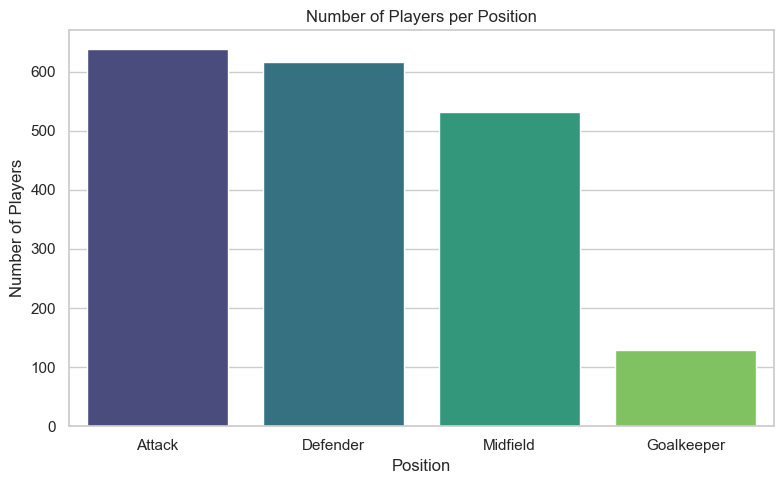

In [9]:
#plot the number of players per position in the dataset 
plt.figure(figsize=(8, 5))
position_counts = train_df['position'].value_counts()
sns.barplot(x=position_counts.index, y=position_counts.values, palette='viridis')
plt.title('Number of Players per Position')
plt.xlabel('Position')
plt.ylabel('Number of Players')
plt.tight_layout()
plt.show()

In [10]:
# Split training data into Outfield Players and Goalkeepers due heavy imbalance of data 
# and is clear that different features will be important
gk_train_df = train_df[train_df['position'] == 'Goalkeeper']
outfield_train_df = train_df[train_df['position'] != 'Goalkeeper']

# Select only numeric columns as cannot calculate correlations for non numeric data
goalkeeper_numeric_df = gk_train_df.select_dtypes(include=[np.number])
outfield_numeric_df = outfield_train_df.select_dtypes(include=[np.number])

#what we are trying to predict 
target = 'transfer_fee'

#total number of outfield players and goalkeepers in the dataset
print(f"Outfield Players: {len(outfield_numeric_df)}")
print(f"Goalkeepers: {len(goalkeeper_numeric_df)}")

Outfield Players: 1786
Goalkeepers: 129


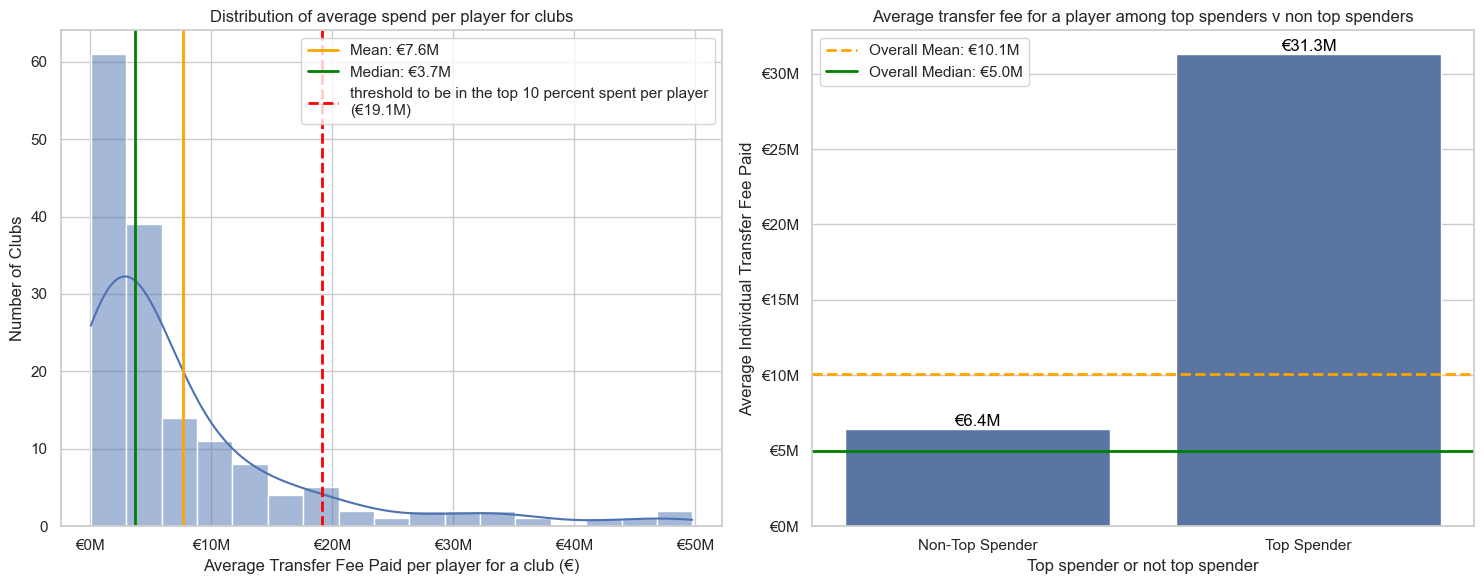

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# DATA PREPARATION FIX
# ==========================================
# 1. Calculate the average spend for each club using 'to_club_name'
average_spend = train_df.groupby('to_club_name')['transfer_fee'].mean().reset_index()
average_spend.rename(columns={'transfer_fee': 'avg_club_spend'}, inplace=True)

# 2. Calculate the threshold for the top 10% of spenders
threshold_top_spender = average_spend['avg_club_spend'].quantile(0.90)

# 3. Identify which clubs are above that threshold
top_spending_clubs = average_spend[average_spend['avg_club_spend'] >= threshold_top_spender]['to_club_name']

# 4. Create the 'Club_Status' column in train_df
train_df['Club_Status'] = np.where(
    train_df['to_club_name'].isin(top_spending_clubs), 
    'Top Spender', 
    'Non-Top Spender'
)

# ==========================================
# PLOTTING
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# histogram showing the number of teams above and below the threshold
# data is what is used to plot the histogram in this case the average spend data
# bins are intervals of the histogram have set this to be decided automatically
# kde draws a line to show the shape of the data
# ax is where the graph is drawn, set to the first column (left) of the grid 
sns.histplot(data=average_spend['avg_club_spend'], bins='auto', kde=True, ax=axes[0])

# --- Calculate mean and median for club spend ---
mean_club_spend = average_spend['avg_club_spend'].mean()
median_club_spend = average_spend['avg_club_spend'].median()

# Add lines for mean and median
axes[0].axvline(mean_club_spend, color='orange', linestyle='-', linewidth=2, label=f'Mean: €{mean_club_spend/1e6:.1f}M')
axes[0].axvline(median_club_spend, color='green', linestyle='-', linewidth=2, label=f'Median: €{median_club_spend/1e6:.1f}M')
# ------------------------------------------------

# draws a line on the first graph at the point on the x-axis where the threshold is 
# dashed line with a thickness of 2
# number is formatted in millions by dividing by 1 million (/1e6) and rounded to 1dp (.1f)
axes[0].axvline(threshold_top_spender, color='red', linestyle='--', linewidth=2, label=f'threshold to be in the top 10 percent spent per player\n(€{threshold_top_spender/1e6:.1f}M)')

axes[0].set_title('Distribution of average spend per player for clubs')
axes[0].set_xlabel('Average Transfer Fee Paid per player for a club (€)')
axes[0].set_ylabel('Number of Clubs')

# draw the label
axes[0].legend()
# formats the x-axis in the same way as earlier in millions
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'€{x/1e6:,.0f}M'))


# ==========================================
# PLOT 2
# ==========================================

# bar chart data is the training data frame, specify categories from the dataframe that should go along the x and y axes 
# and that the graph should be in the second column in the grid 
# and now no error intervals on top of bars
sns.barplot(data=train_df, x='Club_Status', y='transfer_fee', ax=axes[1], errorbar=None)

# --- Calculate overall mean and median for individual transfers ---
mean_transfer = train_df['transfer_fee'].mean()
median_transfer = train_df['transfer_fee'].median()

# Use axhline (horizontal line) because the values are on the y-axis
axes[1].axhline(mean_transfer, color='orange', linestyle='--', linewidth=2, label=f'Overall Mean: €{mean_transfer/1e6:.1f}M')
axes[1].axhline(median_transfer, color='green', linestyle='-', linewidth=2, label=f'Overall Median: €{median_transfer/1e6:.1f}M')

# Add legend to the second plot so the lines are labeled
axes[1].legend()
# ------------------------------------------------------------------

axes[1].set_title('Average transfer fee for a player among top spenders v non top spenders')
axes[1].set_xlabel('Top spender or not top spender')
axes[1].set_ylabel('Average Individual Transfer Fee Paid')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'€{x/1e6:,.0f}M'))

# loop through every bar on the second graph
for bar in axes[1].patches:
    # write the height of each bar which would be the average spend per player and divide by one million to format nicer
    axes[1].annotate(f'€{bar.get_height()/1e6:,.1f}M',
                # specifies where to write the text and font size and color 
                (bar.get_x() + bar.get_width() / 2., bar.get_height()), 
                ha='center', va='bottom', fontsize=12, color='black')

# autoformats the graph in case text is overlapping or getting cutoff
plt.tight_layout()
plt.show()

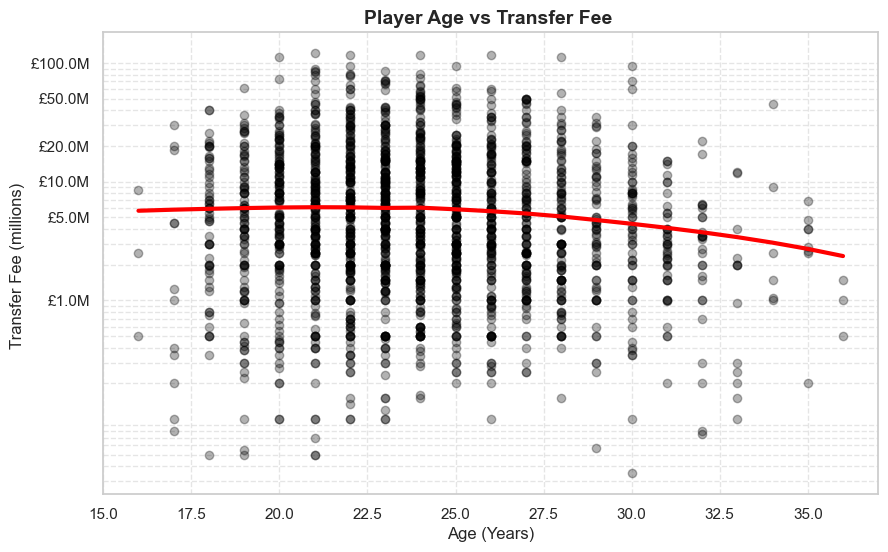

In [12]:


plt.figure(figsize=(10, 6))


agevfee = sns.regplot(
    x='age', 
    y='transfer_fee', 
    data=train_df, 
    scatter_kws={'alpha': 0.3, 'color': 'black'}, 
    line_kws={'color': 'red', 'linewidth': 3},
    lowess=True 
)
# make the scale logarithmic helps by making outliers closer to the rest of the data to allow for curve to look more natural 
plt.yscale('log')


#ScalarFormatter to ensure the numbers aren't shown in scientific notation (1e7)
# division logic to show them in Millions
agevfee.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'£{x/1e6:,.1f}M'))

#set the values that will ne shown on the y axis
agevfee.set_yticks([1e6, 5e6, 10e6, 20e6, 50e6, 100e6]) 

plt.title('Player Age vs Transfer Fee ', fontsize=14, fontweight='bold')
plt.xlabel('Age (Years)')
plt.ylabel('Transfer Fee (millions) ')
plt.grid(True, which="both", ls="--", alpha=0.5) # "both" shows major and minor gridlines

plt.show()

C:\Users\44757\AppData\Local\Temp\ipykernel_68936\2071996923.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_with_target.values, y=corr_with_target.index, palette='viridis')


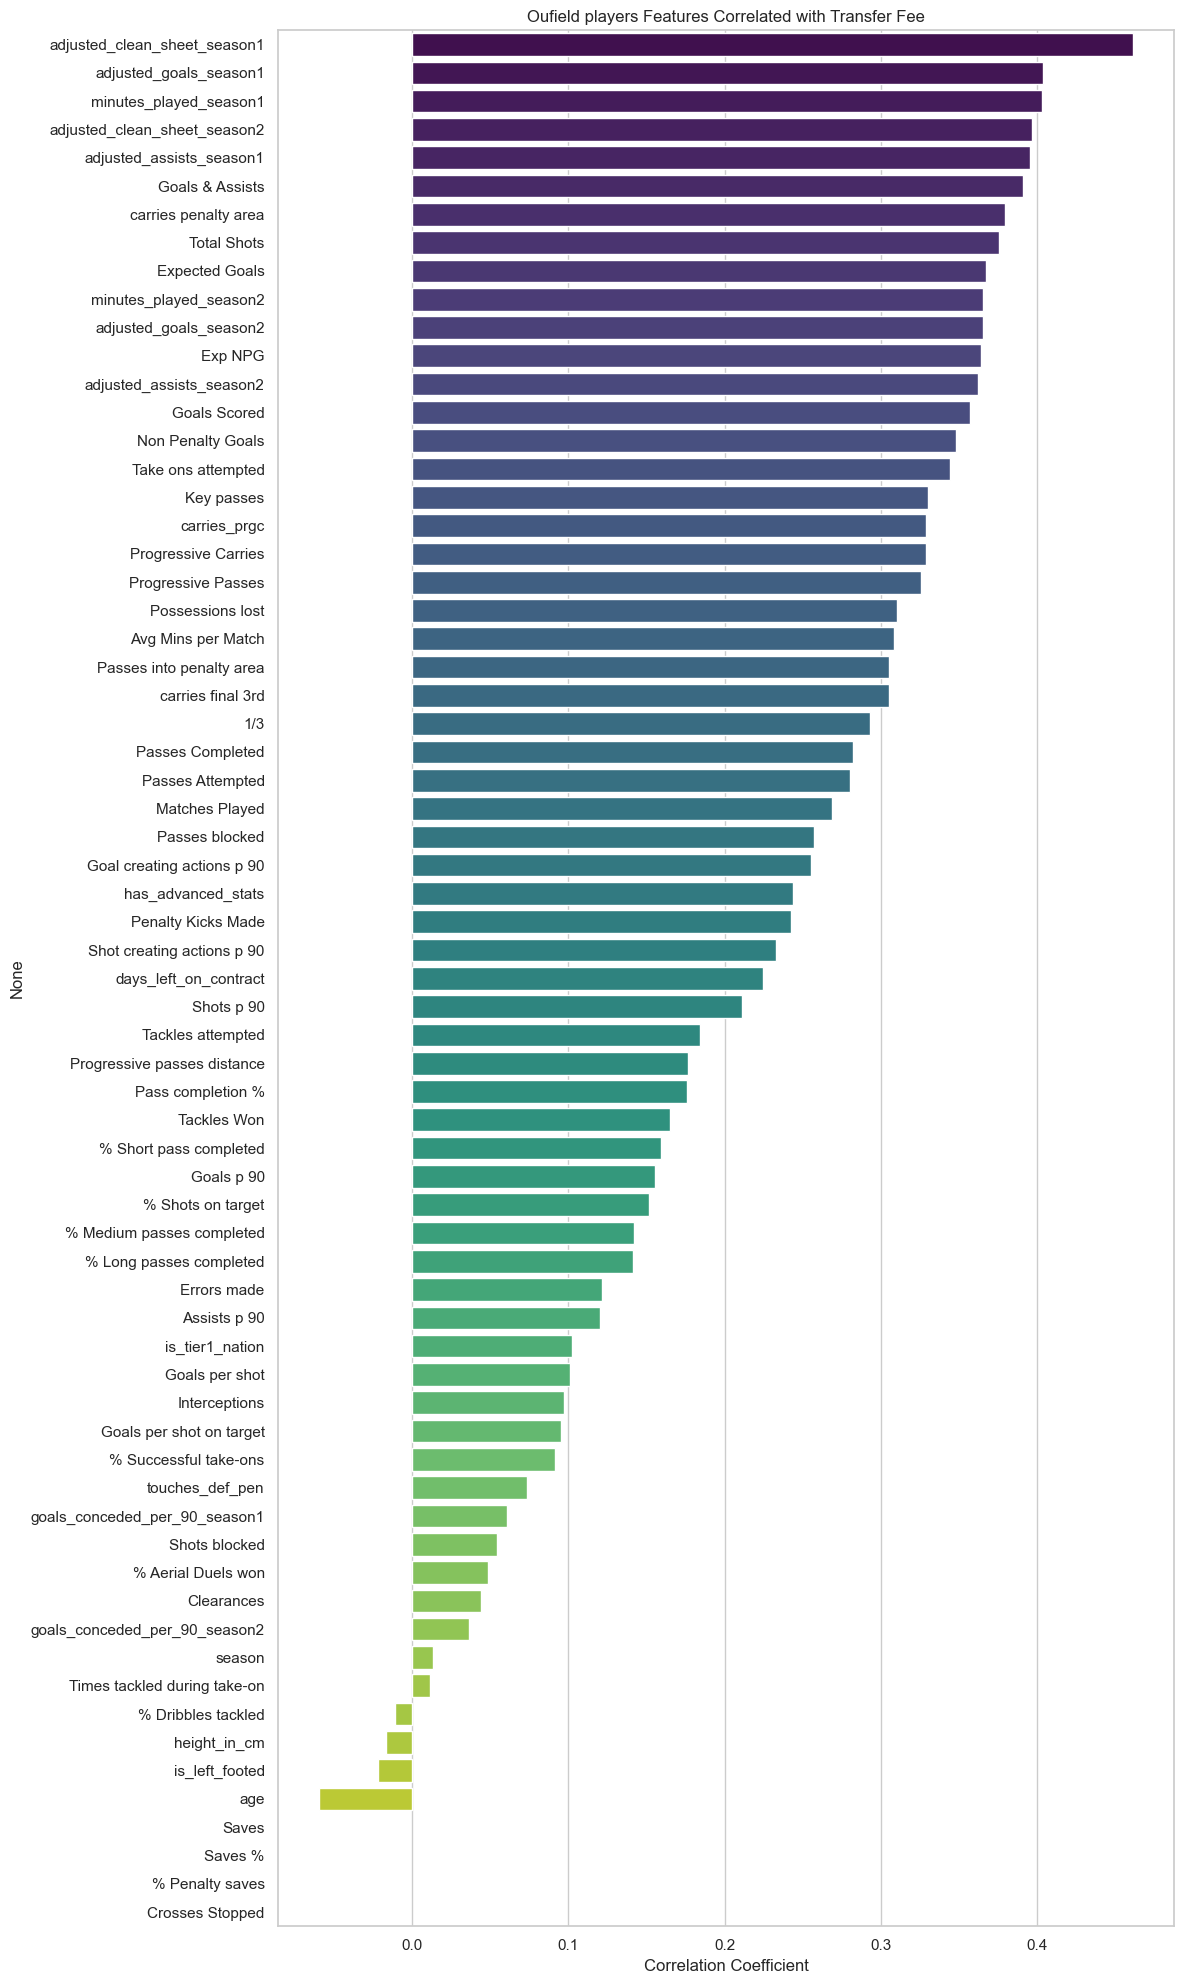

In [13]:
corr_with_target = outfield_numeric_df.corr()[target].drop(target).sort_values(ascending=False)

plt.figure(figsize=(12, 20)) 
sns.barplot(x=corr_with_target.values, y=corr_with_target.index, palette='viridis')
plt.title('Oufield players Features Correlated with Transfer Fee')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

C:\Users\44757\AppData\Local\Temp\ipykernel_68936\2046223526.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_with_target.values, y=corr_with_target.index, palette='viridis')


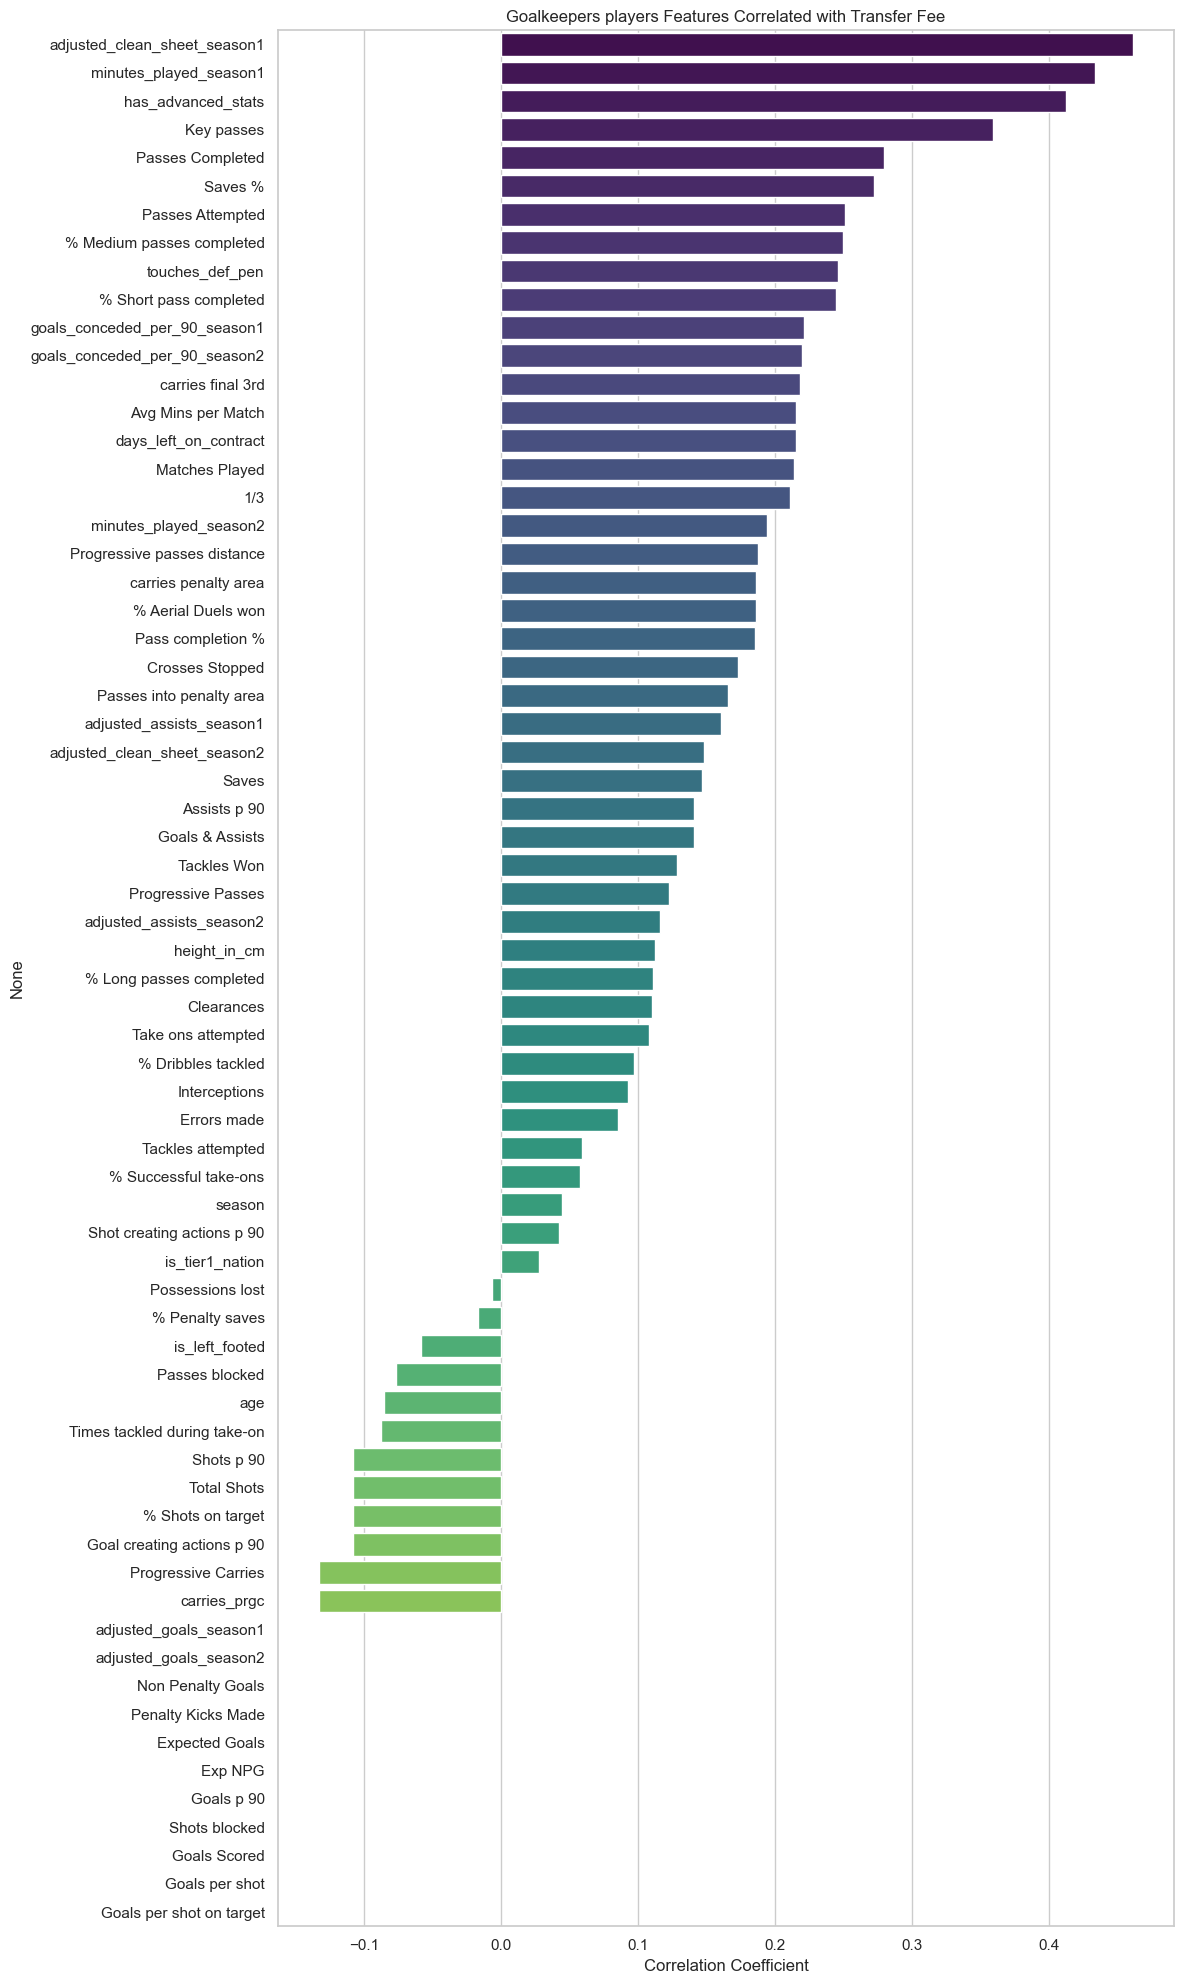

In [14]:
corr_with_target = goalkeeper_numeric_df.corr()[target].drop(target).sort_values(ascending=False)

plt.figure(figsize=(12, 20)) 
sns.barplot(x=corr_with_target.values, y=corr_with_target.index, palette='viridis')
plt.title('Goalkeepers players Features Correlated with Transfer Fee')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

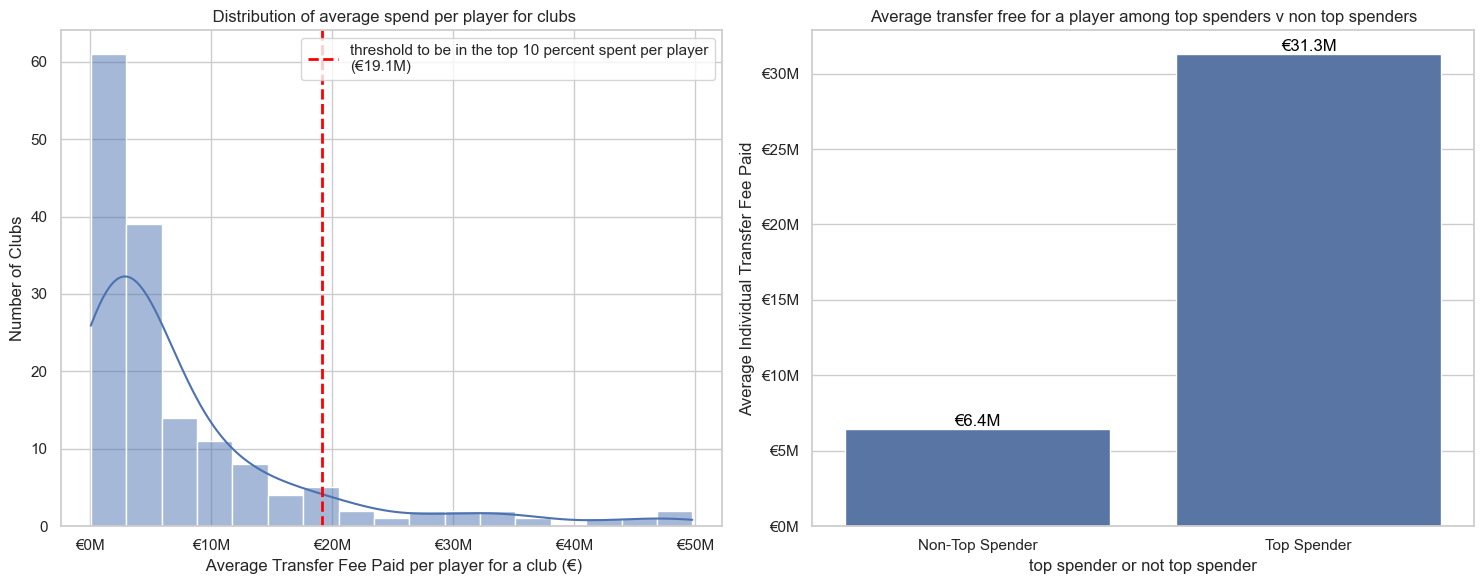

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

#histogram showing the number of teams above and below the threshold
# data is what is used to plot the histogram in this case  the average spend data
#bins are intervals of the histogram have set this to be decided automatically
##kde draws a line to show the shape of the data
# agevfee is the agevfeees where the graoh is draen have set this to the first column (left) of the grid 

sns.histplot(data=average_spend['avg_club_spend'], bins='auto', kde=True, ax=axes[0])

# draws a line on the first graph at the point on the x agevfeeis where the thereshold is 
#dashed line with a thickness of 2
#number is formatted in millions my dividing by 1 million (/1e6) and rounded to 1dp (1f)
axes[0].axvline(threshold_top_spender, color='red', linestyle='--', linewidth=2, label=f'threshold to be in the top 10 percent spent per player\n(€{threshold_top_spender/1e6:.1f}M)')

axes[0].set_title(' Distribution of average spend per player for clubs')
axes[0].set_xlabel(' Average Transfer Fee Paid per player for a club (€)')
axes[0].set_ylabel('Number of Clubs')

#draw the label
axes[0].legend()
#formats the x agevfeeis in the same way as earlier in millions
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'€{x/1e6:,.0f}M'))

#PLOT 2

#bar chart data is the training data frame speciy categories from the dataframe that should go along the x and y agevfeeis 
#and that the graph should be in the second clumn in the  grid 
# and now error intervals on top of bars
sns.barplot(data=train_df, x='Club_Status', y='transfer_fee', ax=axes[1], errorbar=None)
axes[1].set_title('Average transfer free for a player among top spenders v non top spenders')
axes[1].set_xlabel('top spender or not top spender')
axes[1].set_ylabel('Average Individual Transfer Fee Paid')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'€{x/1e6:,.0f}M'))

#loop throgh every bar on the second graph
for bar in axes[1].patches:
    #write the height of each bar which would be the average spend per player and divide by one million to format nicer
    axes[1].annotate(f'€{bar.get_height()/1e6:,.1f}M',
                     #specifies where to write the text and dont size and color 
                (bar.get_x() + bar.get_width() / 2., bar.get_height()), 
                ha='center', va='bottom', fontsize=12, color='black')

#autoformats the graph incase text is overlapping or getting cutoff
plt.tight_layout()
plt.show()

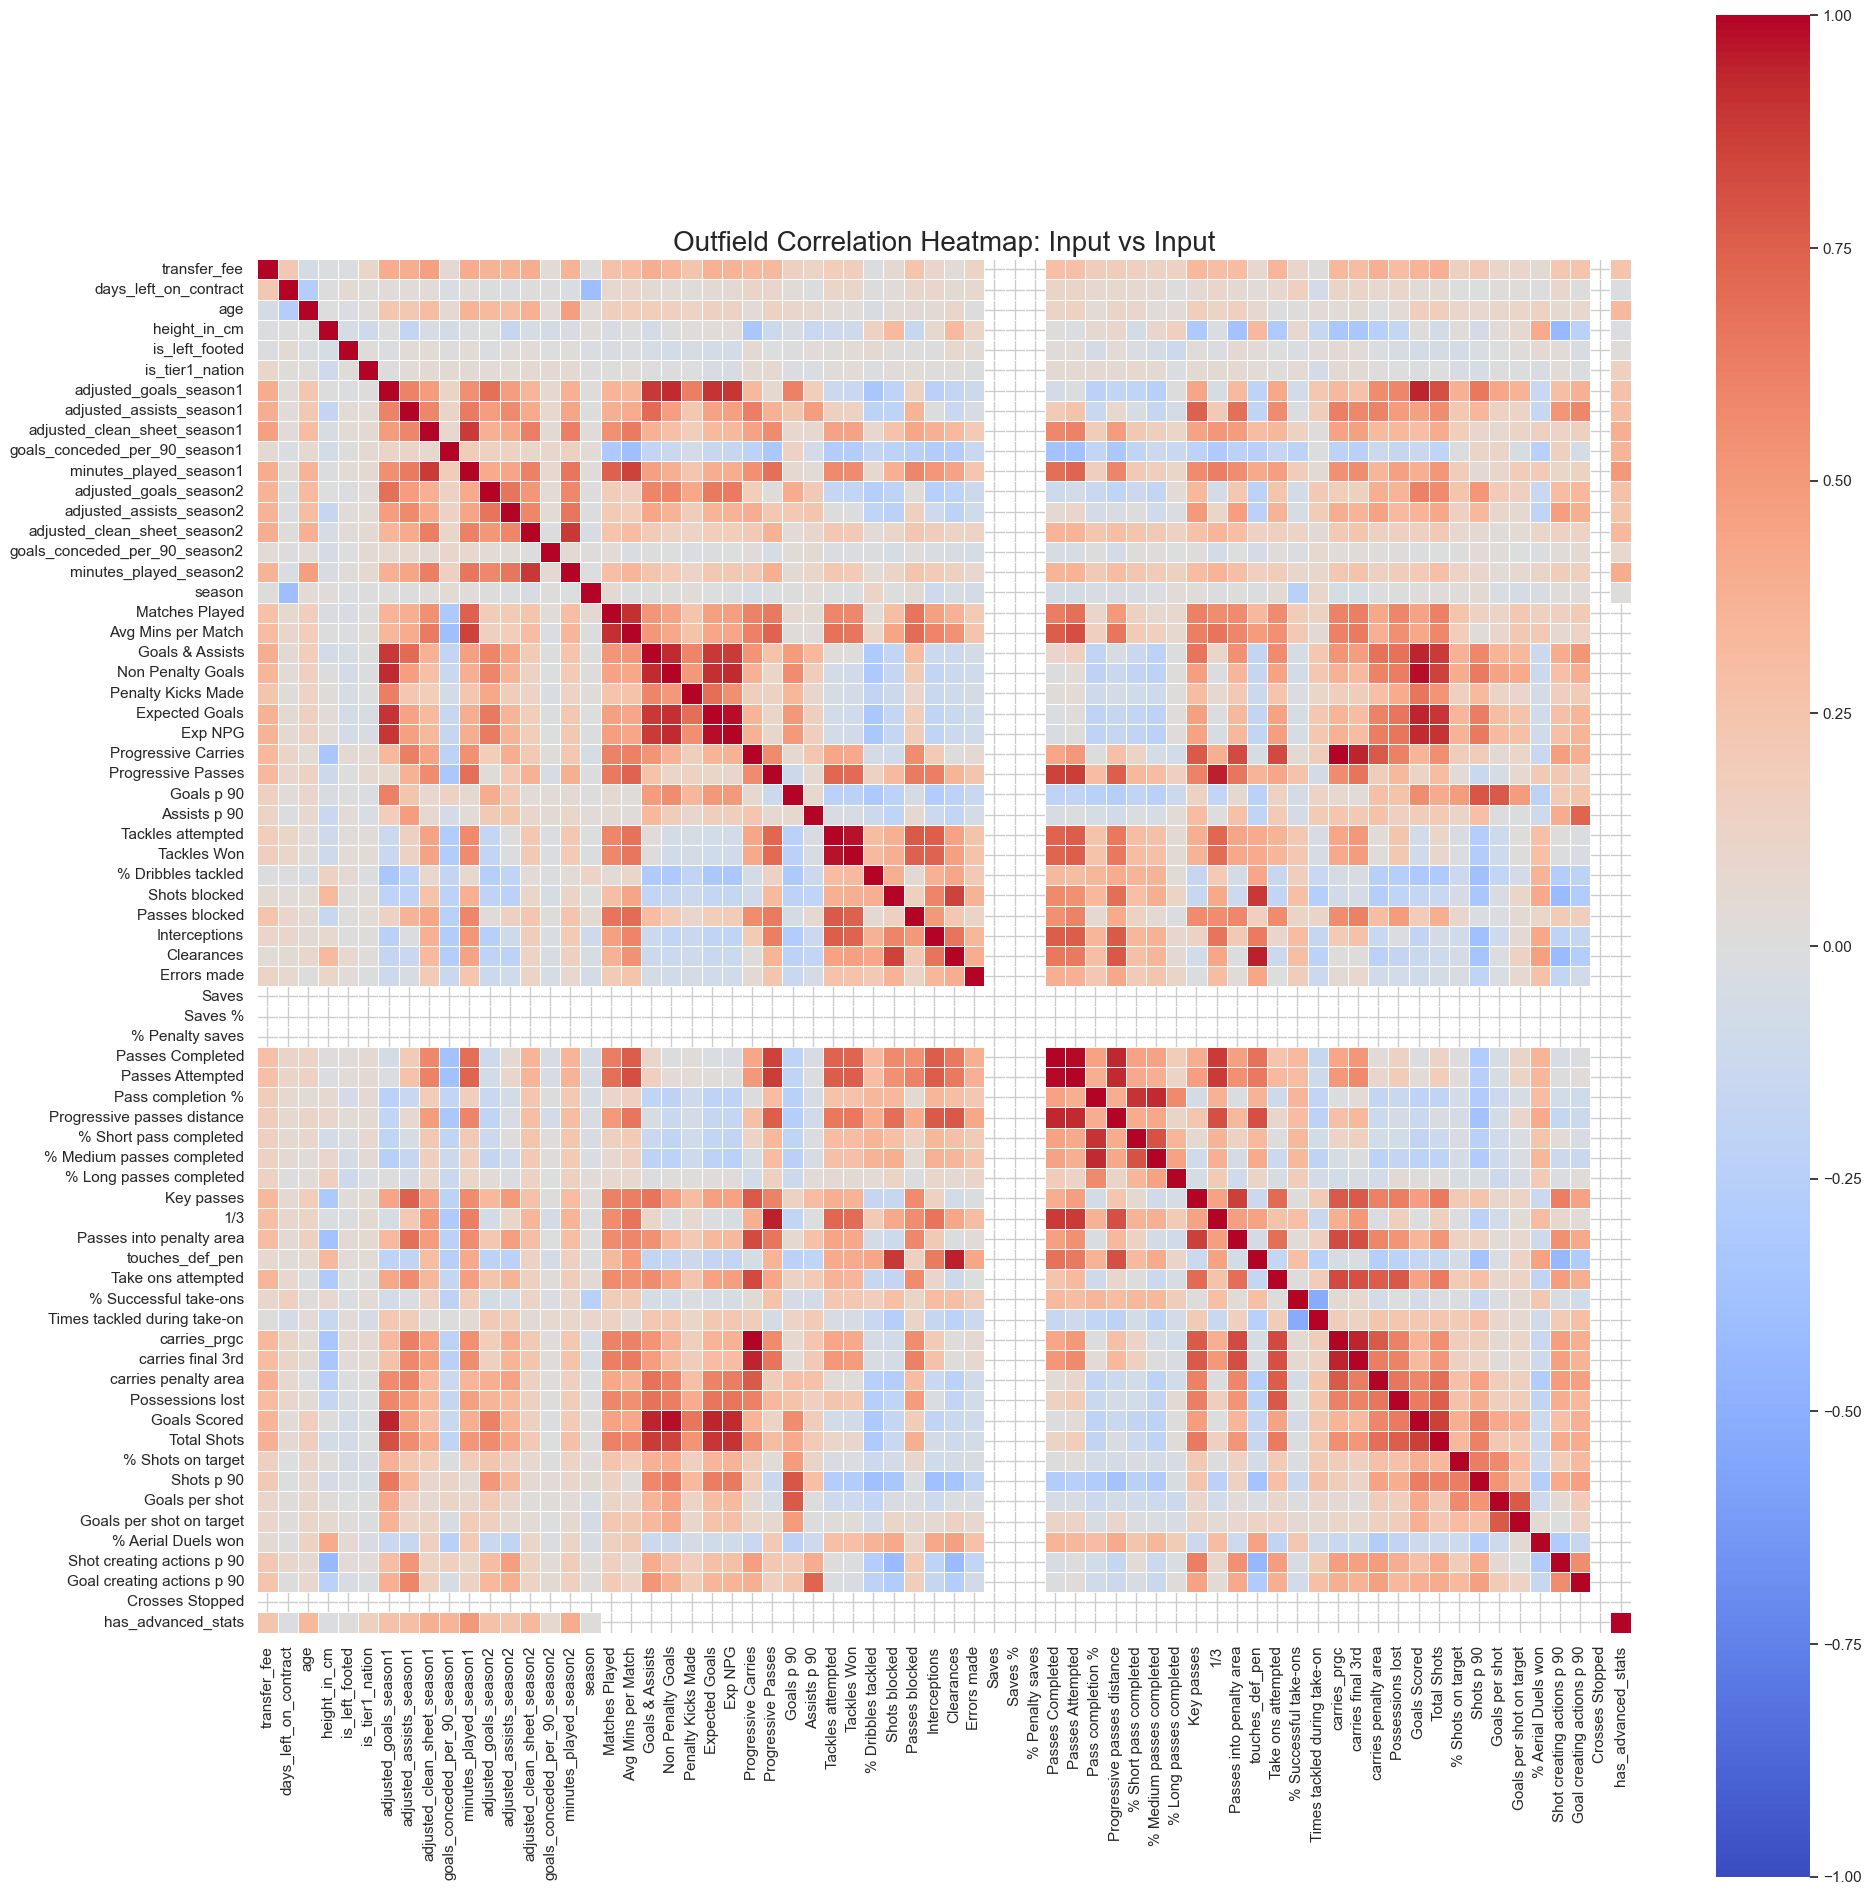

In [16]:
outfield_corr_matrix = outfield_numeric_df.corr()

plt.figure(figsize=(20,20)) 
sns.heatmap(outfield_corr_matrix, 
            cmap='coolwarm', 
            vmin=-1, vmax=1, 
            square=True, 
            linewidths=0.5)

plt.title('Outfield Correlation Heatmap: Input vs Input', fontsize=20)
plt.tight_layout()
plt.show()

# save as a csv file
# Take the  grid and make it into a long list of pairs
corr_pairs = outfield_corr_matrix.unstack().reset_index()

# Rename the columns 
corr_pairs.columns = ['Feature 1', 'Feature 2', 'Correlation']

# Remove pairs comparing a feature to itselff
corr_pairs = corr_pairs[corr_pairs['Feature 1'] != corr_pairs['Feature 2']]

#  Remove duplicates (so we don't see "Age vs Height" and then "Height vs Age" again)
corr_pairs = corr_pairs[corr_pairs['Feature 1'] < corr_pairs['Feature 2']]

#  Drop any empty/missing values 
corr_pairs = corr_pairs.dropna()

# Create a temporary column to find the highest relationships 
#  use .abs() (absolute value) so strong negative numbers (-0.90) jump to the top alongside strong positives (0.90)
corr_pairs['Absolute_Correlation'] = corr_pairs['Correlation'].abs()

#  Sort the list from highest to lowest based on that strength, then delete the temporary column
corr_pairs = corr_pairs.sort_values(by='Absolute_Correlation', ascending=False).drop(columns=['Absolute_Correlation'])

# Round to 2 decimal places and save
corr_pairs['Correlation'] = corr_pairs['Correlation'].round(2)
corr_pairs.to_csv('outfield_pairwise_correlations.csv', index=False)

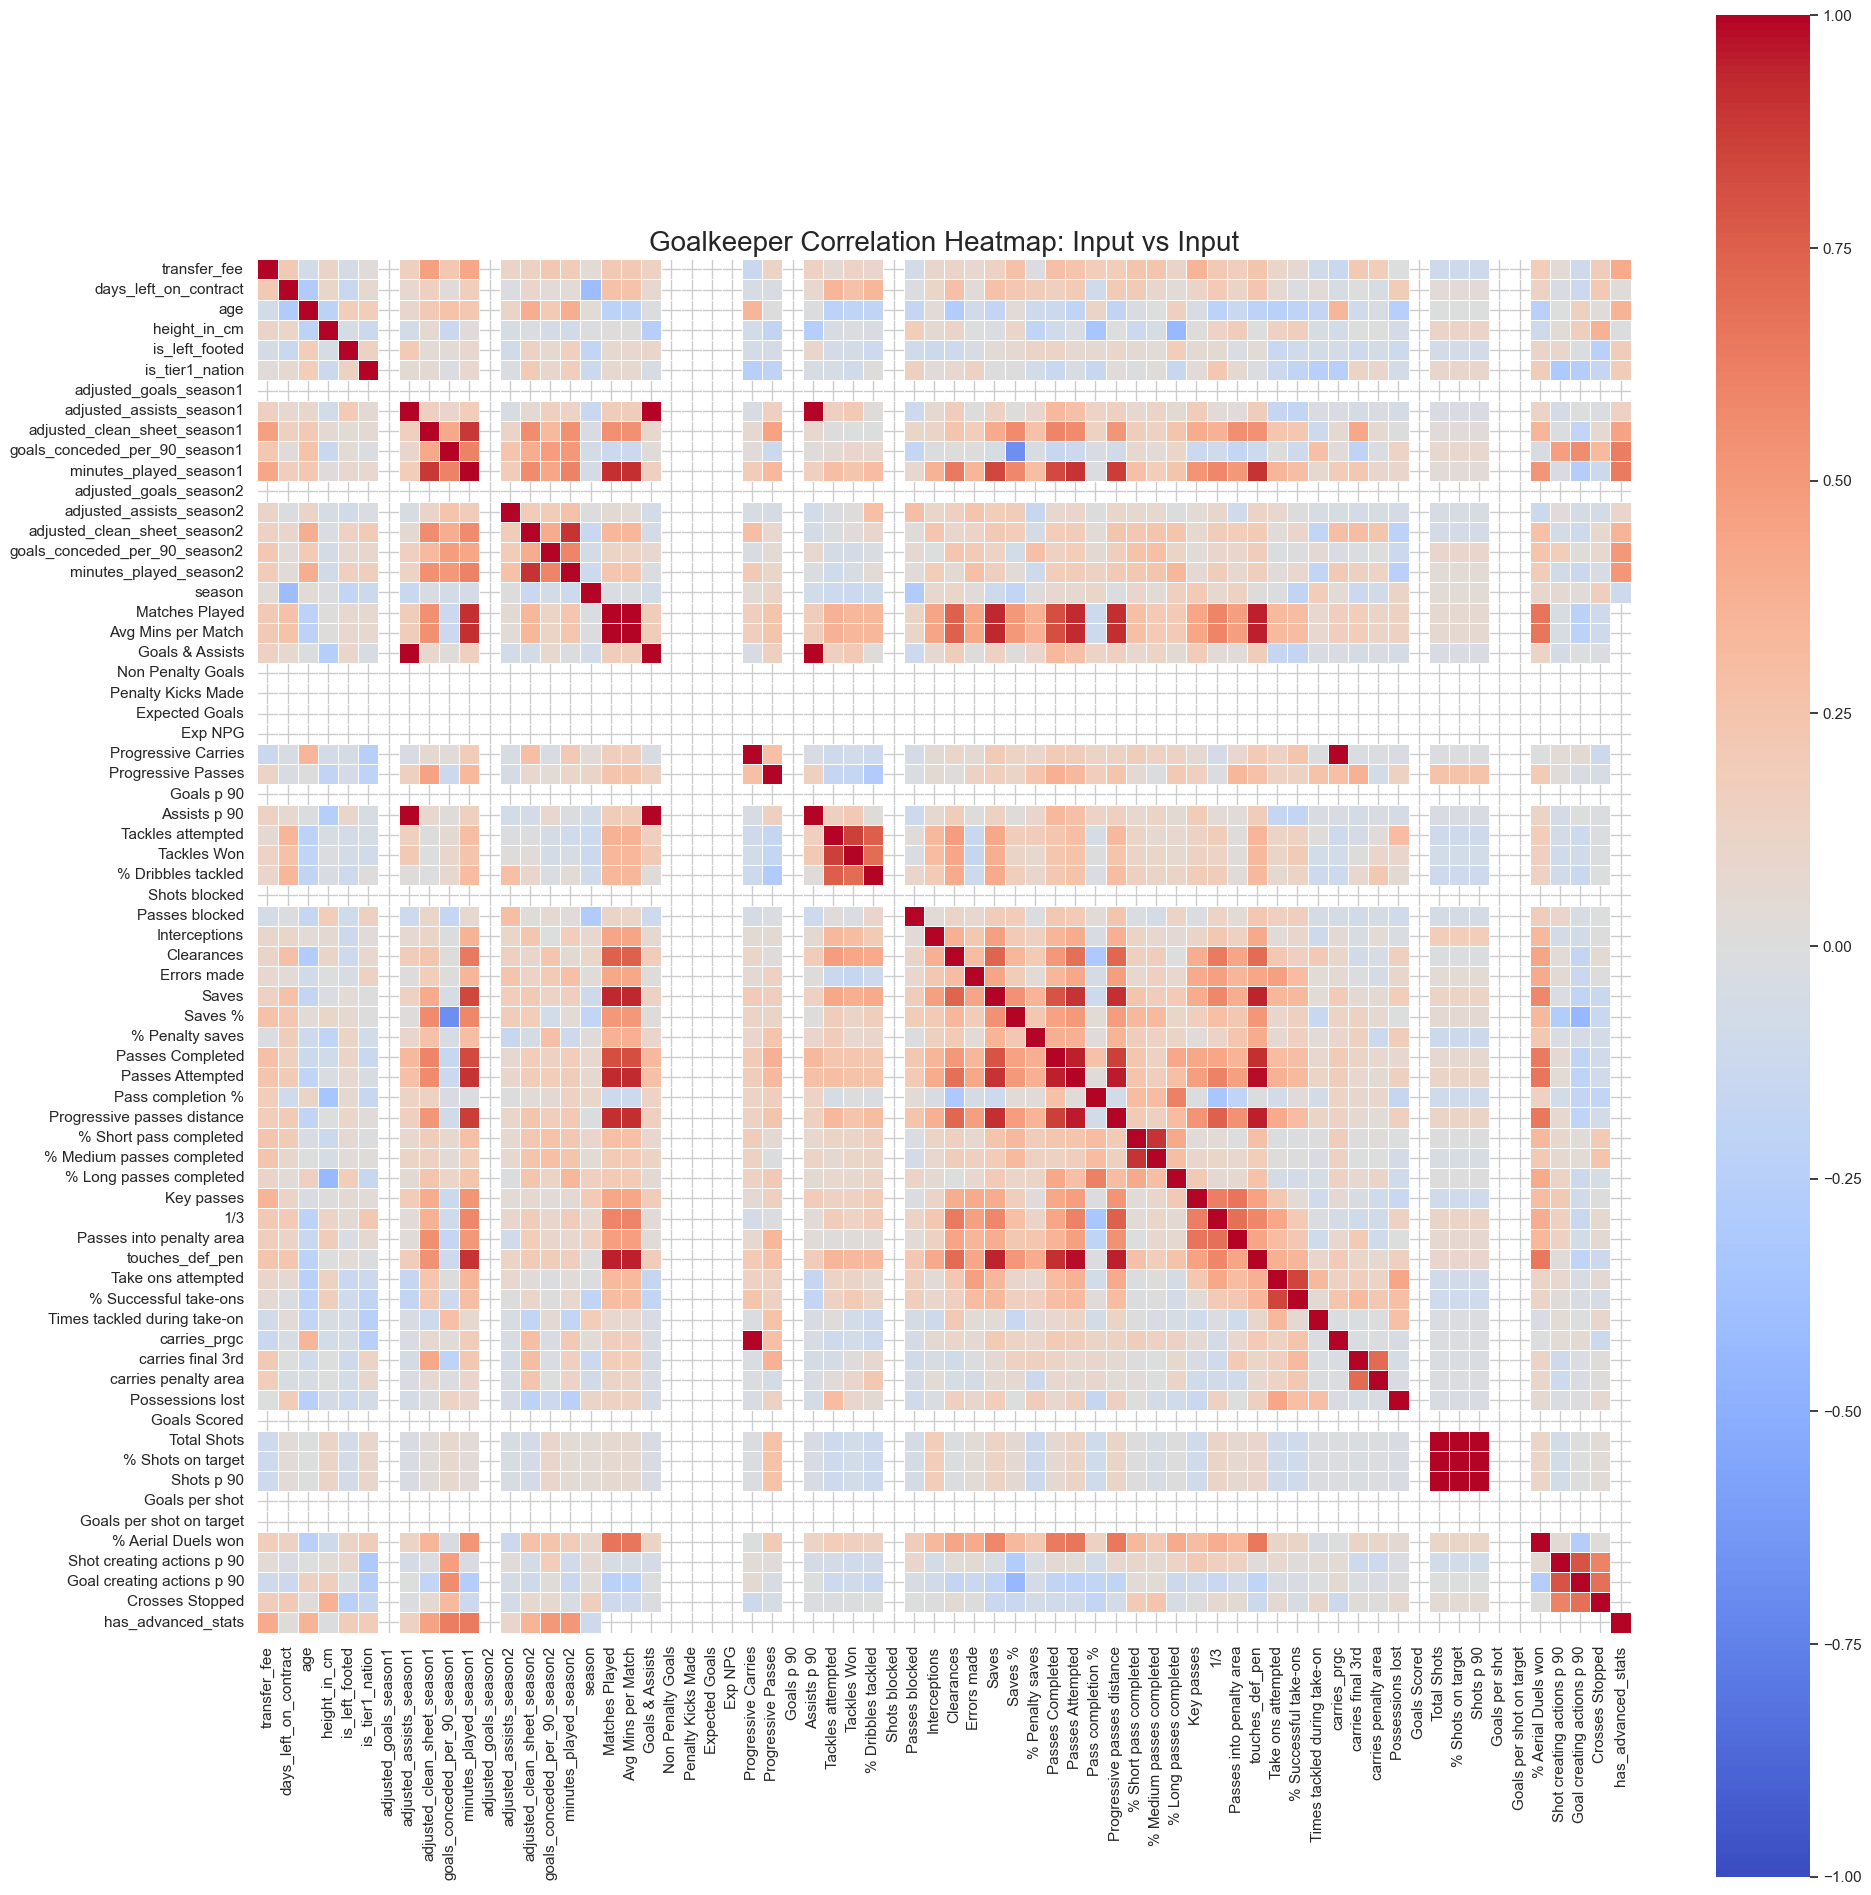

In [17]:
# Calculate the correlation matrix for goalkeepers
goalkeeper_corr_matrix = goalkeeper_numeric_df.corr()

plt.figure(figsize=(20,20)) 
sns.heatmap(goalkeeper_corr_matrix, 
            cmap='coolwarm', 
            vmin=-1, vmax=1, 
            square=True, 
            linewidths=0.5)

plt.title('Goalkeeper Correlation Heatmap: Input vs Input', fontsize=20)
plt.tight_layout()
plt.show()

# save as a csv file
# Take the  grid and make it into a long list of pairs
corr_pairs = goalkeeper_corr_matrix.unstack().reset_index()

# Rename the columns 
corr_pairs.columns = ['Feature 1', 'Feature 2', 'Correlation']

# Remove pairs comparing a feature to itself
corr_pairs = corr_pairs[corr_pairs['Feature 1'] != corr_pairs['Feature 2']]

#  Remove duplicates (so we don't see "Age vs Height" and then "Height vs Age" again)
corr_pairs = corr_pairs[corr_pairs['Feature 1'] < corr_pairs['Feature 2']]

#  Drop any empty/missing values 
corr_pairs = corr_pairs.dropna()

# Create a temporary column to find the highest relationships 
#  use .abs() (absolute value) so strong negative numbers (-0.90) jump to the top alongside strong positives (0.90)
corr_pairs['Absolute_Correlation'] = corr_pairs['Correlation'].abs()

#  Sort the list from highest to lowest based on that strength, then delete the temporary column
corr_pairs = corr_pairs.sort_values(by='Absolute_Correlation', ascending=False).drop(columns=['Absolute_Correlation'])

# Round to 2 decimal places and save
corr_pairs['Correlation'] = corr_pairs['Correlation'].round(2)
corr_pairs.to_csv('goalkeeper_pairwise_correlations.csv', index=False)